# BLINKIT_ANALYSIS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\Python_ML_projects\Blinkit_Project_Python\blinkit_data.csv")
df

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0


In [3]:
df.shape

(8523, 12)

In [4]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

In [5]:
df.dtypes

Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

## Data Cleaning

In [6]:
df["Item Fat Content"].unique()

array(['Regular', 'Low Fat', 'low fat', 'LF', 'reg'], dtype=object)

In [7]:
df["Item Fat Content"] = df["Item Fat Content"].replace({"LF":"Low Fat","reg" : "Regular","low fat":"Low Fat"})

In [8]:
df["Item Fat Content"].unique()

array(['Regular', 'Low Fat'], dtype=object)

# **Business Requirements**

In [9]:
# Total sales

total_sales = df["Sales"].sum()

In [10]:
total_sales

1201681.4808

In [17]:
# Avg sales

Avg_sales = df["Sales"].mean()

In [18]:
Avg_sales

140.9927819781767

In [13]:
# No of itmes sold

no_of_items_sold = df["Sales"].count()

In [14]:
no_of_items_sold

8523

In [15]:
# Avg ratings

Avg_ratings = df["Rating"].mean()

In [16]:
Avg_ratings

3.965857092573038

# ** Charts Requirements**

### Total sales by fat content

In [19]:
df.head(3)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0


In [20]:
sales_by_fat = df.groupby("Item Fat Content")["Sales"].sum()

In [21]:
sales_by_fat

Item Fat Content
Low Fat    776319.6784
Regular    425361.8024
Name: Sales, dtype: float64

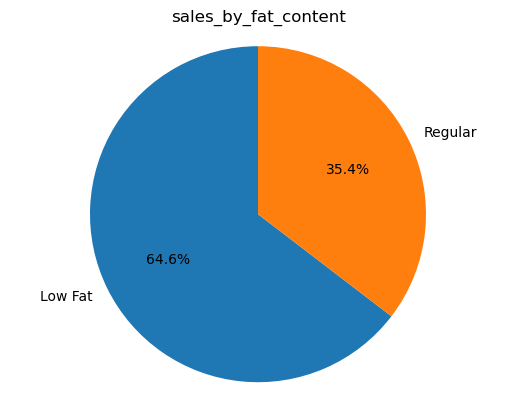

In [30]:
plt.pie(sales_by_fat, labels=sales_by_fat.index, autopct = '%.1f%%',startangle =90)
plt.axis("equal")
plt.title("sales_by_fat_content")
plt.show()

### Total sales by item 

In [36]:
sales_by_type = df.groupby("Item Type")["Sales"].sum().sort_values(ascending = False)

In [37]:
sales_by_type

Item Type
Fruits and Vegetables    178124.0810
Snack Foods              175433.9204
Household                135976.5254
Frozen Foods             118558.8814
Dairy                    101276.4596
Canned                    90706.7270
Baking Goods              81894.7364
Health and Hygiene        68025.8388
Meat                      59449.8638
Soft Drinks               58514.1650
Breads                    35379.1198
Hard Drinks               29334.6766
Others                    22451.8916
Starchy Foods             21880.0274
Breakfast                 15596.6966
Seafood                    9077.8700
Name: Sales, dtype: float64

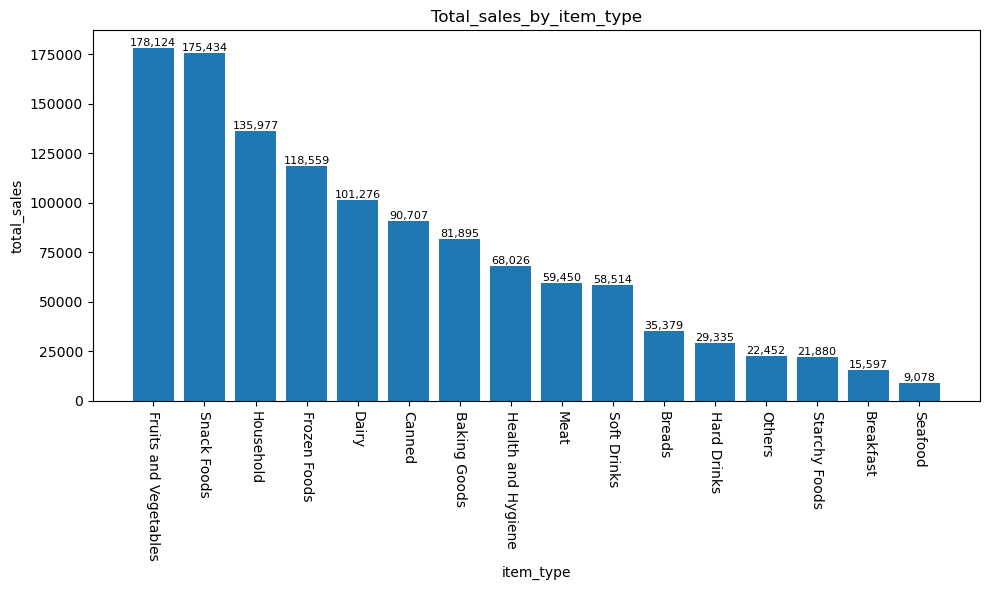

In [43]:
plt.figure(figsize =(10,6))
bars = plt.bar(sales_by_type.index, sales_by_type.values)

plt.xticks(rotation = -90)
plt.xlabel("item_type")
plt.ylabel("total_sales")
plt.title("Total_sales_by_item_type")


for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{bar.get_height():,.0f}',ha= "center", va = "bottom",fontsize = 8)

plt.tight_layout()
plt.show()

### Fat content by outlet for Total sales

In [64]:
grouped = df.groupby(["Outlet Location Type","Item Fat Content"])["Sales"].sum().unstack()
grouped =  grouped[["Regular","Low Fat"]]

In [65]:
Grouped 

Item Fat Content,Low Fat,Regular
Outlet Location Type,,
Tier 1,215047.9126,121349.8994
Tier 2,254464.7734,138685.8682
Tier 3,306806.9924,165326.0348


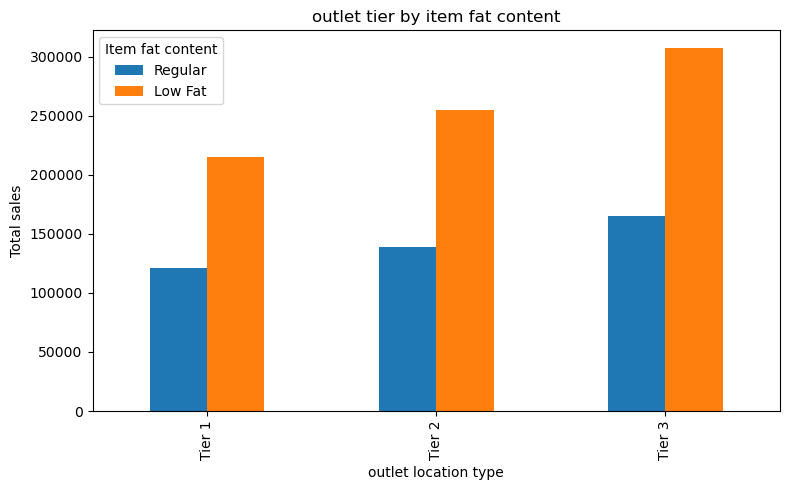

In [66]:
ax = grouped.plot(kind= "bar", figsize = (8,5),title = "outlet tier by item fat content")
plt.xlabel("outlet location type")
plt.ylabel("Total sales")
plt.legend(title = "Item fat content")
plt.tight_layout()
plt.show()

### Toatl sales by outlet establishment

In [72]:
sales_by_year = df.groupby("Outlet Establishment Year")["Sales"].sum().sort_index()

In [73]:
sales_by_year

Outlet Establishment Year
1998    204522.2570
2000    131809.0156
2010    132113.3698
2011     78131.5646
2012    130476.8598
2015    130942.7782
2017    133103.9070
2020    129103.9564
2022    131477.7724
Name: Sales, dtype: float64

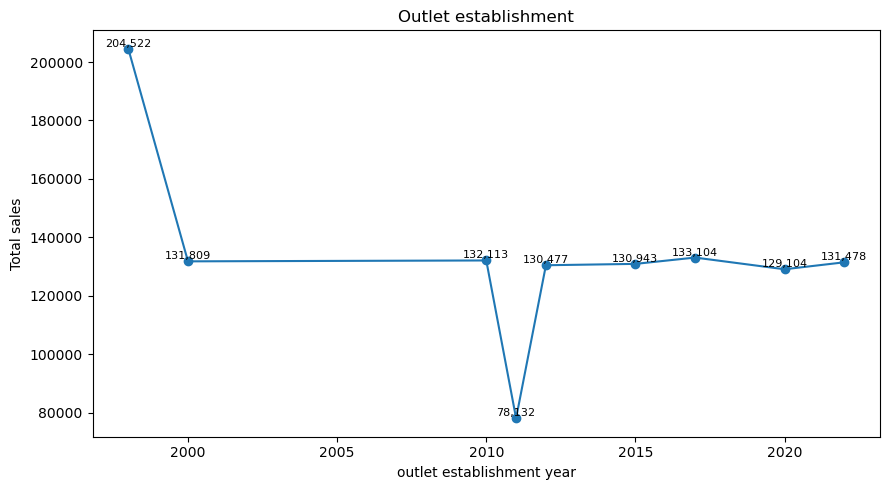

In [74]:
plt.figure(figsize=(9,5))
plt.plot(sales_by_year.index, sales_by_year.values, marker ="o",linestyle="-")

plt.xlabel("outlet establishment year")
plt.ylabel("Total sales")
plt.title("Outlet establishment")

for x,y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(x,y,f'{y:,.0f}', ha = "center", va = "bottom", fontsize = 8)

plt.tight_layout()
plt.show()

# Sales by outlet size

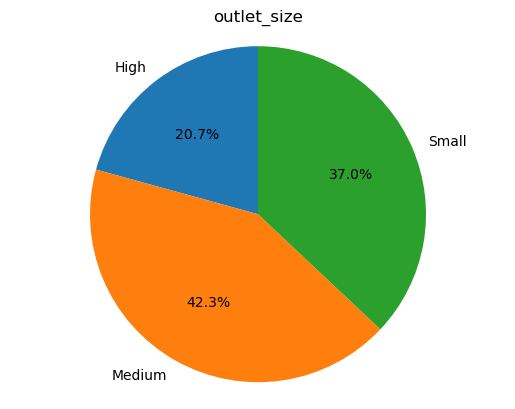

In [76]:
sales_by_size = df.groupby("Outlet Size")["Sales"].sum()


plt.pie(sales_by_size, labels=sales_by_size.index, autopct = '%.1f%%',startangle =90)
plt.axis("equal")
plt.title("outlet_size")
plt.show()

# Total Sales by outlet location type

In [78]:
sales_by_location = df.groupby("Outlet Location Type")["Sales"].sum().reset_index()

sales_by_location = sales_by_location.sort_values("Sales", ascending = False)

In [79]:
sales_by_location

,Outlet Location Type,Sales
2,Tier 3,472133.0272
1,Tier 2,393150.6416
0,Tier 1,336397.8120


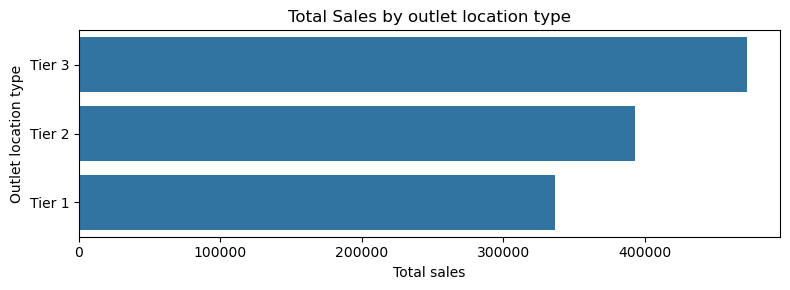

In [82]:
plt.figure(figsize = (8,3))
ax= sns.barplot(x="Sales", y = "Outlet Location Type", data = sales_by_location)

plt.title("Total Sales by outlet location type")
plt.xlabel("Total sales")
plt.ylabel("Outlet location type")

plt.tight_layout()
plt.show()